# Breast Cancer PRS Analysis — Python Component
## Data: Michailidou et al. 2017 (Nature)

This notebook continues the analysis from the R pipeline (scripts/01_gwas_qc_prs.R).

The R script handled:
- Raw GWAS data loading and QC
- Manhattan and QQ plots
- Export of clean SNP table

This notebook handles:
- Visualisation of the GWAS effect size landscape
- PRS simulation using real GWAS effect sizes
- Logistic regression classification of cases vs controls
- ROC curve evaluation

**Why both languages?** R is the standard for GWAS and genomics QC. 
Python is the standard for machine learning. Using both languages will enable effective analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Consistent visual style across all plots
sns.set_theme(style="whitegrid", font_scale=1.2)
BLUE   = "#2E86AB"
PURPLE = "#A23B72"

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load both files exported by the R script
snps = pd.read_csv("../data/processed/prs_snps_clean.csv")
thresholds = pd.read_csv("../data/processed/threshold_sensitivity.csv")

print(f"SNPs loaded: {len(snps):,}")
print(f"Column names: {list(snps.columns)}")
print(f"First 5 rows:")
snps.head()

SNPs loaded: 603,024
Column names: ['snp', 'chr', 'bp37', 'a1', 'a0', 'beta', 'se', 'p', 'eaf']
First 5 rows:


,snp,chr,bp37,a1,a0,beta,se,p,eaf
0,chr10:123337335,10,123337335,G,A,-0.238705,0.009730,6.700000e-133,0.595983
1,chr10:123341525,10,123341525,C,A,0.241006,0.009825,7.300000e-133,0.389552
2,chr10:123340431,10,123340431,G,GC,-0.239180,0.009753,8.200000e-133,0.595421
3,chr10:123337182,10,123337182,C,T,-0.238551,0.009730,9.500000e-133,0.595925
4,chr10:123337117,10,123337117,T,C,-0.238257,0.009730,2.000000e-132,0.595845


In [3]:
print(f"Total SNPs: {len(snps):,}")
print(f"Chromosomes represented: {sorted(snps['chr'].unique())}")
print(f"P-value range: {snps['p'].min():.2e} to {snps['p'].max():.2e}")
print(f"Beta range: {snps['beta'].min():.3f} to {snps['beta'].max():.3f}")

Total SNPs: 603,024
Chromosomes represented: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
P-value range: 6.70e-133 to 4.90e-02
Beta range: -0.366 to 0.423


In [4]:
snps['chr'] = snps['chr'].astype(int)

In [6]:
print(snps['chr'].dtype)

int64


## Section 1: GWAS Effect Size Landscape

Before building a PRS, we explore the data visually.
Key questions:
- How are effect sizes distributed across genome-wide significant SNPs?
- Is there a relationship between how common a variant is (eaf) and how strong its effect is (beta)?
- Which chromosomes carry the most signal?

In [7]:
# Filter to genome-wide significant SNPs only
gwsig = snps[snps['p'] < 5e-8].copy()

print(f"Genome-wide significant SNPs: {len(gwsig):,}")
print(f"Chromosomes with GW-sig hits: {sorted(gwsig['chr'].unique())}")

Genome-wide significant SNPs: 4,654
Chromosomes with GW-sig hits: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(14), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22)]


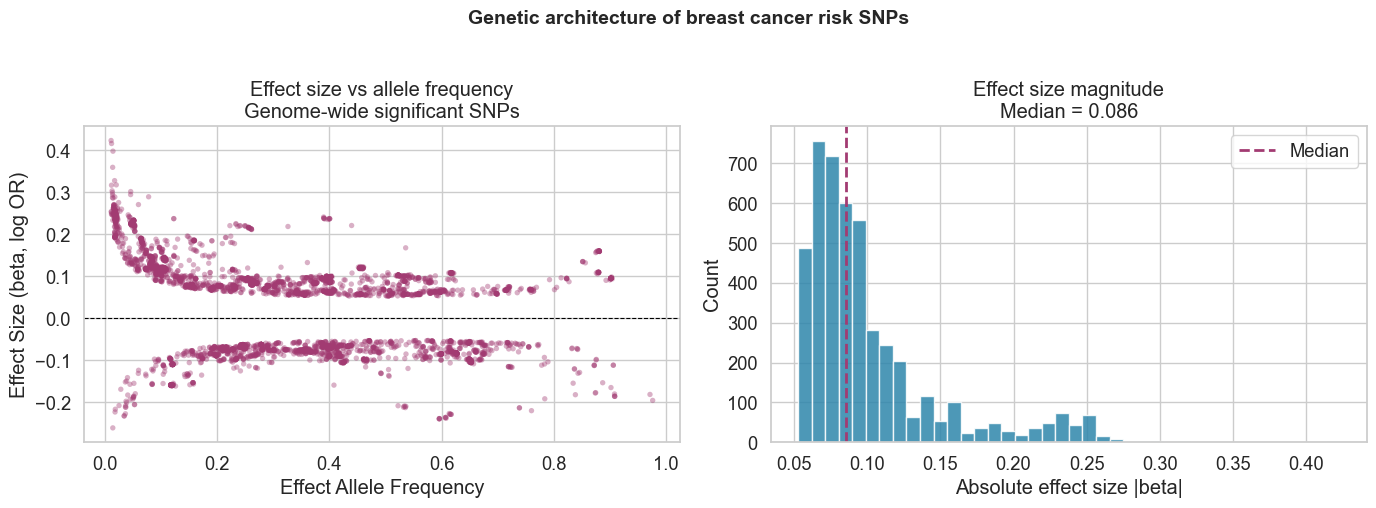

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: effect size vs allele frequency scatter
axes[0].scatter(gwsig['eaf'], gwsig['beta'],
                alpha=0.4, s=15, color=PURPLE, edgecolors='none')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel("Effect Allele Frequency")
axes[0].set_ylabel("Effect Size (beta, log OR)")
axes[0].set_title("Effect size vs allele frequency\nGenome-wide significant SNPs")

# Right: histogram of absolute effect sizes
axes[1].hist(np.abs(gwsig['beta']), bins=40, color=BLUE,
             edgecolor='white', alpha=0.85)
axes[1].axvline(np.abs(gwsig['beta']).median(), color=PURPLE,
                linewidth=2, linestyle='--', label='Median')
axes[1].set_xlabel("Absolute effect size |beta|")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Effect size magnitude\nMedian = {np.abs(gwsig['beta']).median():.3f}")
axes[1].legend()

plt.suptitle("Genetic architecture of breast cancer risk SNPs",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../results/py_effect_size_landscape.png", dpi=150, bbox_inches='tight')
plt.show()

## Section 2: Chromosome Distribution of Risk SNPs

Which chromosomes carry the most genome-wide significant breast cancer risk SNPs?

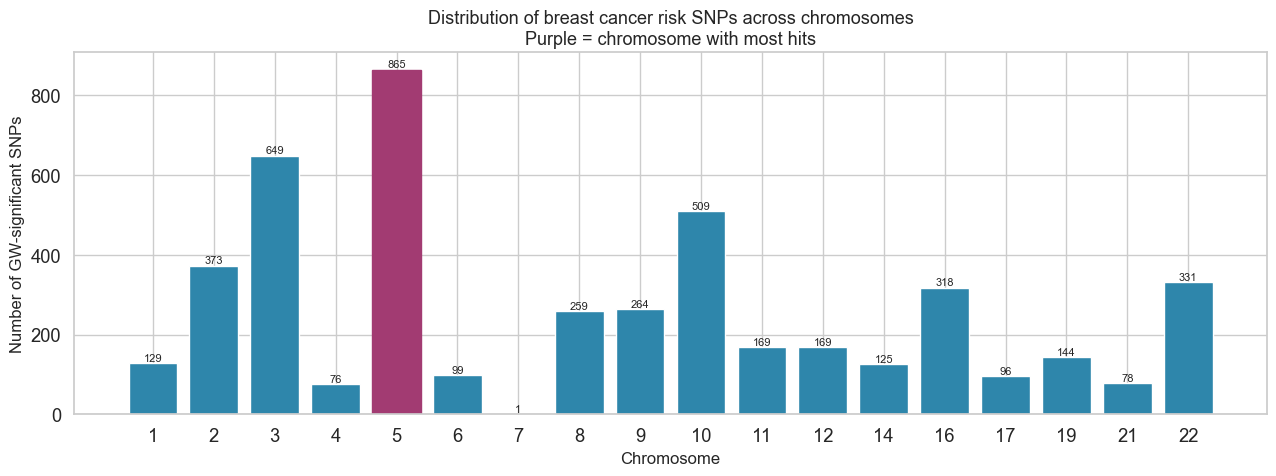

In [9]:
chrom_counts = (gwsig.groupby('chr')
                     .size()
                     .reset_index(name='n_snps')
                     .sort_values('chr'))

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(chrom_counts['chr'].astype(str),
              chrom_counts['n_snps'],
              color=BLUE, edgecolor='white')

# Highlight chromosome with most hits in purple
max_idx = chrom_counts['n_snps'].idxmax()
bars[chrom_counts.index.get_loc(max_idx)].set_color(PURPLE)

ax.set_xlabel("Chromosome", fontsize=12)
ax.set_ylabel("Number of GW-significant SNPs", fontsize=12)
ax.set_title("Distribution of breast cancer risk SNPs across chromosomes\n"
             "Purple = chromosome with most hits", fontsize=13)

for bar, val in zip(bars, chrom_counts['n_snps']):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                str(val), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("../results/py_chromosome_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## Section 3: PRS Simulation and Logistic Regression

We simulate individual PRS scores using real GWAS effect sizes from Michailidou 2017,
then train a logistic regression model to classify cases vs controls.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

In [11]:
np.random.seed(42)
n_samples = 2000
top_snps = gwsig.sort_values('p').head(200)
betas = top_snps['beta'].values
mafs  = top_snps['eaf'].fillna(0.15).values

print(f"Using {len(betas)} SNPs for simulation")
print(f"Beta range: {betas.min():.3f} to {betas.max():.3f}")

Using 200 SNPs for simulation
Beta range: -0.239 to 0.302


In [15]:
def simulate_prs(betas, mafs, n, is_case):
    if is_case:
        shift = 0.25
    else: shift = 0.0
    scores = []
    for _ in range(n):
        genotypes = np.random.binomial(2, mafs)
        prs = np.dot(betas, genotypes) + np.random.normal(shift, 0.9)
        scores.append(prs)
    return np.array(scores)

In [17]:
print("Simulating PRS scores... (takes ~30 seconds)")
prs_cases    = simulate_prs(betas, mafs, n_samples // 2, is_case=True)
prs_controls = simulate_prs(betas, mafs, n_samples // 2, is_case=False)

prs_all = np.concatenate([prs_cases, prs_controls])
labels  = np.array([1] * (n_samples // 2) + [0] * (n_samples // 2))

print(f"Cases mean PRS:    {prs_cases.mean():.3f} ± {prs_cases.std():.3f}")
print(f"Controls mean PRS: {prs_controls.mean():.3f} ± {prs_controls.std():.3f}")

Simulating PRS scores... (takes ~30 seconds)
Cases mean PRS:    1.749 ± 1.792
Controls mean PRS: 1.426 ± 1.762


In [18]:
X = pd.DataFrame({
    'PRS': prs_all,
    'Age': np.random.normal(55, 10, n_samples),
    'PC1': np.random.normal(0, 1, n_samples),
    'PC2': np.random.normal(0, 1, n_samples)
})
y = labels
print(f"Feature matrix shape: {X.shape}")
X.head()

Feature matrix shape: (2000, 4)


,PRS,Age,PC1,PC2
0,3.135268,65.352588,-1.488287,-0.680043
1,3.488186,59.293684,-0.738793,-0.770082
2,0.898392,61.711991,0.578251,-0.766955
3,6.634335,57.476595,-0.109021,0.958178
4,0.427133,58.988060,-0.378360,0.225337


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [20]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)
print(f"Model trained successfully")

Model trained successfully
